# Feature Engineering and Clustering Experiments  
**TF-IDF, LDA Topic Vectors, and SBERT Embeddings**

**Feature engineering + clustering**

**Inputs:** `arxiv_clustering_cleaned_data_.csv` (pre-cleaned 150-word title+abstract records)  
**Outputs:** Feature matrices + cluster assignment artifacts saved under `outputs/`

> Reproducibility note: random seeds are fixed; splits are stratified by label.


## 1. Environment Setup and Imports


In [ ]:

# (Uncomment if required)
# !pip install -q pandas numpy scipy scikit-learn matplotlib nltk sentence-transformers umap-learn seaborn

import os
import re
import json
import math
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# INPUT PATH TO DATA HERE
INPUT_CSV = r"C:\Users\kylew\OneDrive\Documents\GitHub\Personal\DTI5125-Data-Science-Applications\Assignment-2-clustering\data\arxiv_clustering_cleaned_data_.csv"

OUT_DIR = "outputs"
OUT_FEATURES = os.path.join(OUT_DIR, "features")
OUT_ASSIGN = os.path.join(OUT_DIR, "cluster_assignments")
OUT_FIG = os.path.join(OUT_DIR, "figures")

for p in [OUT_DIR, OUT_FEATURES, OUT_ASSIGN, OUT_FIG]:
    os.makedirs(p, exist_ok=True)

print("Output directories ready:", OUT_DIR)


Output directories ready: outputs


## 2. Dataset Loading and Integrity Checks


In [21]:

df = pd.read_csv(INPUT_CSV)

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Expected minimal schema for this notebook
required_cols = ["text", "label"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create a stable doc_id
df = df.reset_index(drop=True).copy()
df["doc_id"] = df.index.astype(int)

# Basic integrity checks
assert df["text"].isna().sum() == 0, "Missing text values found."
assert df["label"].isna().sum() == 0, "Missing label values found."

print("\nLabel distribution:")
display(df["label"].value_counts())

# Word-count sanity (expects about 150 words, but we tolerate small deviations)
df["wc"] = df["text"].astype(str).str.split().str.len()
print("\nWord-count summary:")
display(df["wc"].describe())

# Optional: flag unusually short/long records (should be rare)
short = (df["wc"] < 120).sum()
long = (df["wc"] > 180).sum()
print(f"\nRecords with wc < 120: {short} | wc > 180: {long}")


Shape: (1000, 9)
Columns: ['text', 'label', 'year', 'authors', 'title', 'abstract', 'title_word_count', 'abstract_word_count', 'total_word_count']

Label distribution:


label
Computer Vision     200
Cryptography        200
Machine Learning    200
NLP                 200
Robotics            200
Name: count, dtype: int64


Word-count summary:


count    1000.0
mean      150.0
std         0.0
min       150.0
25%       150.0
50%       150.0
75%       150.0
max       150.0
Name: wc, dtype: float64


Records with wc < 120: 0 | wc > 180: 0


In [22]:

# --- Create stratified splits (train/val/test) for fair comparison across features ---

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_df["label"]
)

df["split"] = "unused"
df.loc[train_df.index, "split"] = "train"
df.loc[val_df.index, "split"]   = "val"
df.loc[test_df.index, "split"]  = "test"

print(df["split"].value_counts())
print("\nTrain label distribution:")
display(df[df["split"]=="train"]["label"].value_counts())


split
train    700
val      150
test     150
Name: count, dtype: int64

Train label distribution:


label
Computer Vision     140
Cryptography        140
Machine Learning    140
NLP                 140
Robotics            140
Name: count, dtype: int64

## 3. Text Normalization Pipeline (Feature-Independent)


Input `text` is already lowercased and cleaned, apply a light, deterministic normalization
so that TF-IDF, LDA, and SBERT consume identical text.


In [23]:

def normalize_text(s: str) -> str:
    s = str(s)
    # Collapse whitespace, strip
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_norm"] = df["text"].map(normalize_text)

# Quick check
display(df[["doc_id", "label", "split", "text_norm"]].head())


,doc_id,label,split,text_norm
0,0,Computer Vision,train,noise aware learning web crawled image text da...
1,1,Computer Vision,val,bringing object life training free generation ...
2,2,Computer Vision,train,videorefer suite advancing spatial temporal ob...
3,3,Computer Vision,train,prototypical distillation debiased tuning blac...
4,4,Computer Vision,train,h nerf surface hyperspectral reconstruction st...


## 4. TF-IDF Feature Engineering


### 4.1 Motivation
TF-IDF is a strong lexical baseline for clustering scientific abstracts.


### 4.2 Vectorizer Configuration


In [24]:

tfidf_cfg = dict(
    lowercase=False,          # already normalized
    ngram_range=(1, 2),       # unigrams + bigrams help technical phrases
    min_df=5,                 # drop extremely rare terms
    max_df=0.90,              # drop ubiquitous terms
    max_features=50000        # cap for memory stability
)

tfidf = TfidfVectorizer(**tfidf_cfg)


### 4.3 Vectorization Execution


In [25]:

train_texts = df.loc[df["split"]=="train", "text_norm"].tolist()
val_texts   = df.loc[df["split"]=="val",   "text_norm"].tolist()
test_texts  = df.loc[df["split"]=="test",  "text_norm"].tolist()

X_tfidf_train = tfidf.fit_transform(train_texts)
X_tfidf_val   = tfidf.transform(val_texts)
X_tfidf_test  = tfidf.transform(test_texts)

print("TF-IDF shapes:", X_tfidf_train.shape, X_tfidf_val.shape, X_tfidf_test.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

# Persist features
from scipy import sparse
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_train.npz"), X_tfidf_train)
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_val.npz"),   X_tfidf_val)
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_test.npz"),  X_tfidf_test)

with open(os.path.join(OUT_FEATURES, "tfidf_vocabulary.json"), "w", encoding="utf-8") as f:
    json.dump(tfidf.vocabulary_, f, default=int)

print("Saved TF-IDF feature matrices to:", OUT_FEATURES)


TF-IDF shapes: (700, 3383) (150, 3383) (150, 3383)
Vocabulary size: 3383
Saved TF-IDF feature matrices to: outputs\features


### 4.4 Diagnostic Outputs


In [26]:

# Show a small sample of high-IDF terms (rare but informative terms)
idf = tfidf.idf_
terms = np.array(tfidf.get_feature_names_out())
top_idf_idx = np.argsort(idf)[-20:][::-1]
diag = pd.DataFrame({"term": terms[top_idf_idx], "idf": idf[top_idf_idx]})
display(diag)


,term,idf
0,adaptability,5.760748
1,action execution,5.760748
2,action model,5.760748
3,abrupt,5.760748
4,add,5.760748
5,without training,5.760748
6,work introduce,5.760748
7,voice,5.760748
8,work leverage,5.760748
9,abstract,5.760748


## 5. LDA Topic Modeling


### 5.1 Conceptual Explanation
LDA yields interpretable topic vectors (doc to topic mixture) that can be clustered like any other feature space.


### 5.2 Topic Number Selection


In [27]:

# LDA uses a count-based representation
count_cfg = dict(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    max_features=50000
)

count_vec = CountVectorizer(**count_cfg)

X_cnt_train = count_vec.fit_transform(train_texts)
X_cnt_val   = count_vec.transform(val_texts)
X_cnt_test  = count_vec.transform(test_texts)

print("Count matrix shapes:", X_cnt_train.shape, X_cnt_val.shape, X_cnt_test.shape)
print("Count vocabulary size:", len(count_vec.vocabulary_))


Count matrix shapes: (700, 3383) (150, 3383) (150, 3383)
Count vocabulary size: 3383


### 5.3 Model Training


In [28]:

# Start with 5 topics (matches the number of human categories),
# and also produce 8 and 10 topics for robustness.
topic_counts = [5, 8, 10]

lda_models = {}
doc_topic = {}

for k in topic_counts:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_SEED,
        learning_method="batch",
        max_iter=30,
        evaluate_every=-1,
    )
    lda.fit(X_cnt_train)
    lda_models[k] = lda

    # doc-topic distributions
    dt_train = lda.transform(X_cnt_train)
    dt_val   = lda.transform(X_cnt_val)
    dt_test  = lda.transform(X_cnt_test)

    doc_topic[k] = dict(train=dt_train, val=dt_val, test=dt_test)

    # Save doc-topic matrices
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_train_k{k}.npy"), dt_train)
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_val_k{k}.npy"),   dt_val)
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_test_k{k}.npy"),  dt_test)

print("Saved LDA doc-topic matrices for k in", topic_counts)


Saved LDA doc-topic matrices for k in [5, 8, 10]


### 5.4 Topic Interpretation


In [29]:

def top_words_per_topic(lda_model, feature_names, top_n=10):
    topics = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_idx = topic.argsort()[-top_n:][::-1]
        topics.append((topic_idx, [feature_names[i] for i in top_idx]))
    return topics

feature_names = np.array(count_vec.get_feature_names_out())

for k, lda in lda_models.items():
    print(f"\nTop words per topic (k={k}):")
    topics = top_words_per_topic(lda, feature_names, top_n=10)
    for topic_idx, words in topics:
        print(f"  Topic {topic_idx:02d}: {', '.join(words)}")



Top words per topic (k=5):
  Topic 00: model, language, task, video, training, fine, visual, language model, reasoning, benchmark
  Topic 01: model, language, llm, based, language model, large, human, study, ai, large language
  Topic 02: model, image, method, data, feature, learning, based, network, representation, training
  Topic 03: learning, robot, policy, agent, real, environment, multi, based, world, model
  Topic 04: learning, data, attack, based, network, system, privacy, model, security, detection

Top words per topic (k=8):
  Topic 00: model, video, language, visual, task, vision, image, training, data, text
  Topic 01: model, time, based, transformer, framework, attention, ai, image, series, multi
  Topic 02: model, method, feature, representation, data, training, object, image, learning, token
  Topic 03: learning, agent, policy, robot, rl, reinforcement, environment, real, multi, reinforcement learning
  Topic 04: attack, learning, data, network, based, privacy, adversar

### 5.5 Export Features


In [30]:

# For clustering, use doc-topic matrix as dense feature vectors.
# Export CSV for k=5 (the canonical choice), and keep others as .npy.

k_can = 5
dt_all = np.vstack([
    doc_topic[k_can]["train"],
    doc_topic[k_can]["val"],
    doc_topic[k_can]["test"]
])

# Recover row order corresponding to concatenation
df_order = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy()

assert len(df_order) == dt_all.shape[0]

dt_cols = [f"topic_{i}" for i in range(dt_all.shape[1])]
lda_feat_df = pd.DataFrame(dt_all, columns=dt_cols)
lda_feat_df.insert(0, "doc_id", df_order["doc_id"].values)

lda_csv = os.path.join(OUT_FEATURES, "lda_topic_vectors_k5.csv")
lda_feat_df.to_csv(lda_csv, index=False)
print("Saved:", lda_csv)


Saved: outputs\features\lda_topic_vectors_k5.csv


## 6. SBERT Embedding Generation


### 6.1 Motivation
SBERT embeddings often cluster better semantically than BoW/TF-IDF, but with reduced interpretability.


### 6.2 Model Choice
A compact model is recommended for speed (here: `all-MiniLM-L6-v2`).


In [31]:

# If sentence-transformers is unavailable, install it in your environment.
try:
    from sentence_transformers import SentenceTransformer
except Exception as e:
    raise ImportError(
        "sentence-transformers not available. Install via `pip install sentence-transformers`."
    ) from e

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
sbert = SentenceTransformer(SBERT_MODEL_NAME)

print("Loaded SBERT:", SBERT_MODEL_NAME)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SBERT: all-MiniLM-L6-v2


### 6.3 Embedding Computation


In [32]:

# Encode in split blocks to keep memory predictable.
def encode_texts(model, texts, batch_size=64):
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,  # cosine similarity becomes dot product
    )
    return np.asarray(emb, dtype=np.float32)

E_train = encode_texts(sbert, train_texts, batch_size=64)
E_val   = encode_texts(sbert, val_texts,   batch_size=64)
E_test  = encode_texts(sbert, test_texts,  batch_size=64)

print("SBERT shapes:", E_train.shape, E_val.shape, E_test.shape)

np.save(os.path.join(OUT_FEATURES, "sbert_train.npy"), E_train)
np.save(os.path.join(OUT_FEATURES, "sbert_val.npy"),   E_val)
np.save(os.path.join(OUT_FEATURES, "sbert_test.npy"),  E_test)

with open(os.path.join(OUT_FEATURES, "sbert_model.json"), "w", encoding="utf-8") as f:
    json.dump({"model": SBERT_MODEL_NAME, "normalized": True}, f)

print("Saved SBERT embeddings to:", OUT_FEATURES)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

SBERT shapes: (700, 384) (150, 384) (150, 384)
Saved SBERT embeddings to: outputs\features


### 6.4 Embedding Diagnostics


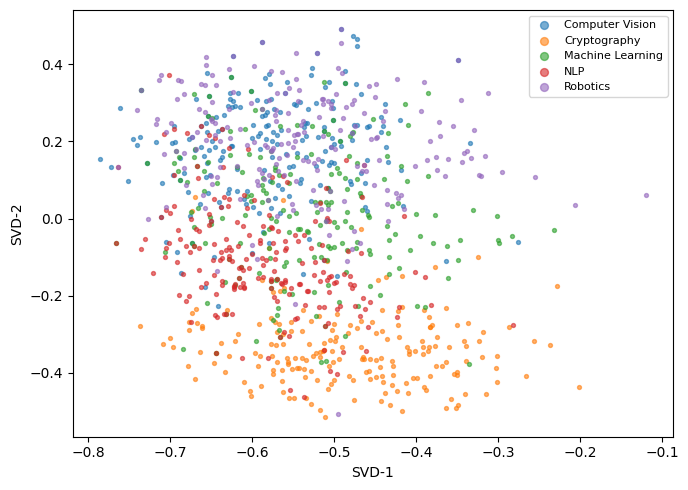

In [33]:

# Quick 2D diagnostic via TruncatedSVD (PCA-like for large matrices)
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
E2 = svd2.fit_transform(np.vstack([E_train, E_val, E_test]))

df_order = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy()

plt.figure(figsize=(7, 5))
for lab in sorted(df_order["label"].unique()):
    m = (df_order["label"] == lab).values
    plt.scatter(E2[m, 0], E2[m, 1], s=8, alpha=0.6, label=lab)
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "sbert_svd2_scatter_by_label.png"), dpi=200)
plt.show()


## 7. Clustering Pipeline (Common Framework)


We run the same clustering algorithms across feature spaces, exporting a standardized assignment file for each run.
Cluster *evaluation* (kappa, silhouette, coherence) is handled by next; this notebook focuses on generating
clean, reproducible cluster assignments and associated artifacts.


In [34]:

@dataclass
class RunSpec:
    feature_type: str
    method: str
    variant: str  # linkage / covariance etc.
    k: int

def export_assignments(df_block: pd.DataFrame, cluster_ids: np.ndarray, spec: RunSpec, out_path: str):
    out = df_block[["doc_id", "label", "split"]].copy()
    out = out.rename(columns={"label": "true_label"})
    out["feature_type"] = spec.feature_type
    out["clustering_method"] = spec.method
    out["variant"] = spec.variant
    out["k"] = spec.k
    out["cluster_id"] = cluster_ids.astype(int)
    out.to_csv(out_path, index=False)
    return out_path

def concat_splits(train_arr, val_arr, test_arr):
    return np.vstack([train_arr, val_arr, test_arr])

df_all_ordered = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy().reset_index(drop=True)

print("Ordered rows:", df_all_ordered.shape)


Ordered rows: (1000, 13)


## 8. K-Means Clustering


### 8.1 Configuration


In [35]:

K_CLUSTERS = 5

kmeans_cfg = dict(
    n_clusters=K_CLUSTERS,
    n_init=20,
    random_state=RANDOM_SEED
)


### 8.2 Execution Across Feature Types


In [36]:

from scipy import sparse

# Load TF-IDF from disk to ensure use of persisted artifacts
X_tfidf_train = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_train.npz"))
X_tfidf_val   = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_val.npz"))
X_tfidf_test  = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_test.npz"))

X_tfidf_all = sparse.vstack([X_tfidf_train, X_tfidf_val, X_tfidf_test])

# LDA (k=5 topics) already as dense
dt_train = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_train_k5.npy"))
dt_val   = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_val_k5.npy"))
dt_test  = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_test_k5.npy"))
X_lda_all = concat_splits(dt_train, dt_val, dt_test)

# SBERT embeddings
E_train = np.load(os.path.join(OUT_FEATURES, "sbert_train.npy"))
E_val   = np.load(os.path.join(OUT_FEATURES, "sbert_val.npy"))
E_test  = np.load(os.path.join(OUT_FEATURES, "sbert_test.npy"))
X_sbert_all = concat_splits(E_train, E_val, E_test)

runs = []

# KMeans on TF-IDF (sparse)
km = KMeans(**kmeans_cfg)
tfidf_labels = km.fit_predict(X_tfidf_all)
path = os.path.join(OUT_ASSIGN, "kmeans_tfidf.csv")
runs.append(export_assignments(df_all_ordered, tfidf_labels, RunSpec("tfidf","kmeans","default",K_CLUSTERS), path))

# KMeans on LDA topic vectors (dense)
km = KMeans(**kmeans_cfg)
lda_labels = km.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "kmeans_lda_k5.csv")
runs.append(export_assignments(df_all_ordered, lda_labels, RunSpec("lda_topics_k5","kmeans","default",K_CLUSTERS), path))

# KMeans on SBERT (dense)
km = KMeans(**kmeans_cfg)
sbert_labels = km.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "kmeans_sbert.csv")
runs.append(export_assignments(df_all_ordered, sbert_labels, RunSpec("sbert","kmeans","default",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\kmeans_tfidf.csv
 - outputs\cluster_assignments\kmeans_lda_k5.csv
 - outputs\cluster_assignments\kmeans_sbert.csv


### 8.3 Preliminary Diagnostics


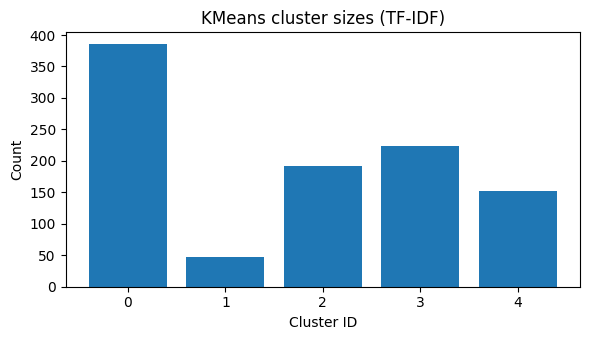

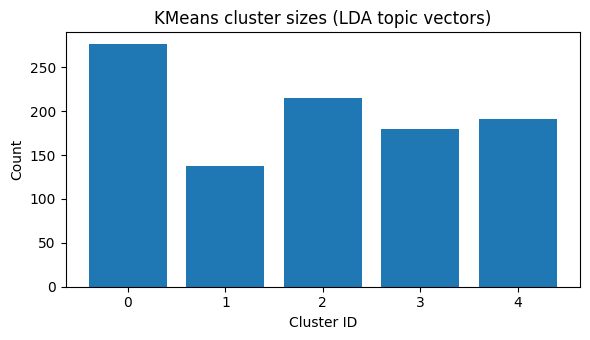

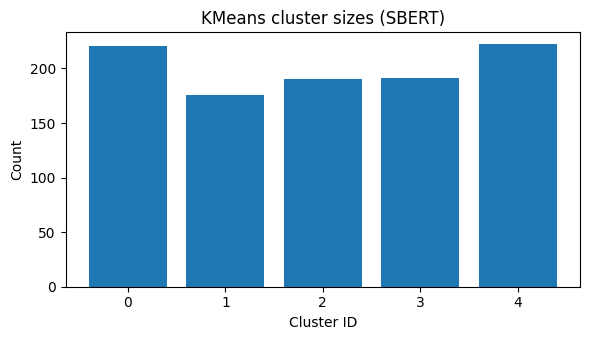

In [37]:

def plot_cluster_sizes(cluster_ids, title, outname):
    counts = pd.Series(cluster_ids).value_counts().sort_index()
    plt.figure(figsize=(6, 3.5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Cluster ID")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, outname), dpi=200)
    plt.show()

plot_cluster_sizes(tfidf_labels, "KMeans cluster sizes (TF-IDF)", "kmeans_tfidf_cluster_sizes.png")
plot_cluster_sizes(lda_labels,   "KMeans cluster sizes (LDA topic vectors)", "kmeans_lda_cluster_sizes.png")
plot_cluster_sizes(sbert_labels, "KMeans cluster sizes (SBERT)", "kmeans_sbert_cluster_sizes.png")


## 9. Gaussian Mixture (EM) Clustering


### 9.1 Motivation
GMM provides soft assignments (probabilities), often reflecting overlap between adjacent categories.


### 9.2 Model Settings


In [38]:

# GMM expects dense input. For TF-IDF, we reduce dimensionality with TruncatedSVD.
SVD_DIM = 100

svd = TruncatedSVD(n_components=SVD_DIM, random_state=RANDOM_SEED)
X_tfidf_svd = svd.fit_transform(X_tfidf_all)

print("TF-IDF reduced shape:", X_tfidf_svd.shape)


TF-IDF reduced shape: (1000, 100)


### 9.3 Execution


In [39]:

gmm_cfg = dict(
    n_components=K_CLUSTERS,
    random_state=RANDOM_SEED,
    covariance_type="diag",
    max_iter=300
)

runs = []

# GMM on TF-IDF (reduced)
gmm = GaussianMixture(**gmm_cfg)
gmm_tfidf = gmm.fit_predict(X_tfidf_svd)
path = os.path.join(OUT_ASSIGN, "gmm_tfidf_svd100_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_tfidf, RunSpec("tfidf_svd100","gmm","diag",K_CLUSTERS), path))

# GMM on LDA vectors
gmm = GaussianMixture(**gmm_cfg)
gmm_lda = gmm.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "gmm_lda_k5_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_lda, RunSpec("lda_topics_k5","gmm","diag",K_CLUSTERS), path))

# GMM on SBERT
gmm = GaussianMixture(**gmm_cfg)
gmm_sbert = gmm.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "gmm_sbert_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_sbert, RunSpec("sbert","gmm","diag",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\gmm_tfidf_svd100_diag.csv
 - outputs\cluster_assignments\gmm_lda_k5_diag.csv
 - outputs\cluster_assignments\gmm_sbert_diag.csv


## 10. Hierarchical Clustering


### 10.1 Motivation
Hierarchical clustering can reveal coarse-to-fine relationships (e.g., ML to NLP to CV overlap).


### 10.2 Linkage Strategies
Run (1) Ward linkage on reduced Euclidean space and (2) Average linkage with cosine metric where applicable.


### 10.3 Execution


In [40]:

runs = []

# TF-IDF: use SVD-reduced for Ward linkage (Euclidean)
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_tfidf_ward = ward.fit_predict(X_tfidf_svd)
path = os.path.join(OUT_ASSIGN, "hier_tfidf_svd100_ward.csv")
runs.append(export_assignments(df_all_ordered, h_tfidf_ward, RunSpec("tfidf_svd100","hierarchical","ward",K_CLUSTERS), path))

# TF-IDF: average linkage with cosine metric (on normalized dense low-dim space)
# To keep memory stable, reuse SVD space and L2 normalize
X_tfidf_svd_norm = normalize(X_tfidf_svd)
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_tfidf_avg = avg_cos.fit_predict(X_tfidf_svd_norm)
path = os.path.join(OUT_ASSIGN, "hier_tfidf_svd100_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_tfidf_avg, RunSpec("tfidf_svd100","hierarchical","average_cosine",K_CLUSTERS), path))

# LDA: ward (Euclidean) works naturally on low-dimensional dense vectors
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_lda_ward = ward.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "hier_lda_k5_ward.csv")
runs.append(export_assignments(df_all_ordered, h_lda_ward, RunSpec("lda_topics_k5","hierarchical","ward",K_CLUSTERS), path))

# LDA: average cosine
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_lda_avg = avg_cos.fit_predict(normalize(X_lda_all))
path = os.path.join(OUT_ASSIGN, "hier_lda_k5_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_lda_avg, RunSpec("lda_topics_k5","hierarchical","average_cosine",K_CLUSTERS), path))

# SBERT: average cosine is a natural default
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_sbert_avg = avg_cos.fit_predict(X_sbert_all)  # embeddings already normalized
path = os.path.join(OUT_ASSIGN, "hier_sbert_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_sbert_avg, RunSpec("sbert","hierarchical","average_cosine",K_CLUSTERS), path))

# SBERT: ward on euclidean (works, but less principled for cosine-optimized embeddings)
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_sbert_ward = ward.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "hier_sbert_ward.csv")
runs.append(export_assignments(df_all_ordered, h_sbert_ward, RunSpec("sbert","hierarchical","ward",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\hier_tfidf_svd100_ward.csv
 - outputs\cluster_assignments\hier_tfidf_svd100_avgcos.csv
 - outputs\cluster_assignments\hier_lda_k5_ward.csv
 - outputs\cluster_assignments\hier_lda_k5_avgcos.csv
 - outputs\cluster_assignments\hier_sbert_avgcos.csv
 - outputs\cluster_assignments\hier_sbert_ward.csv


## 11. Consolidated Artifact Export


In [41]:

# Merge all assignment CSVs into one master table for next phase
assign_files = [os.path.join(OUT_ASSIGN, f) for f in os.listdir(OUT_ASSIGN) if f.endswith(".csv")]
assign_files = sorted(assign_files)

frames = [pd.read_csv(p) for p in assign_files]
master = pd.concat(frames, axis=0, ignore_index=True)

master_path = os.path.join(OUT_ASSIGN, "MASTER_cluster_assignments.csv")
master.to_csv(master_path, index=False)

print("Wrote master assignments:", master_path)
print("Rows:", master.shape[0])
display(master.head())


Wrote master assignments: outputs\cluster_assignments\MASTER_cluster_assignments.csv
Rows: 24000


,doc_id,true_label,split,feature_type,clustering_method,variant,k,cluster_id
0,0,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
1,2,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
2,3,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
3,4,Computer Vision,train,lda_topics_k5,gmm,diag,5,2
4,5,Computer Vision,train,lda_topics_k5,gmm,diag,5,3


## 12. Verification and Validation Section


In [42]:

# Basic verification checks

# 1) Expected splits
assert set(df["split"].unique()) == {"train","val","test"}, "Unexpected split values."

# 2) Expected number of clusters produced in each run
bad = []
for p in assign_files:
    d = pd.read_csv(p)
    k = d["cluster_id"].nunique()
    if k != K_CLUSTERS:
        bad.append((os.path.basename(p), k))

if bad:
    print("WARNING: Some runs did not produce K clusters:")
    for name, k in bad:
        print(" -", name, "clusters:", k)
else:
    print("All runs produced exactly", K_CLUSTERS, "clusters.")

# 3) No missing cluster labels
assert master["cluster_id"].isna().sum() == 0, "Missing cluster ids in master."

print("Verification complete.")


All runs produced exactly 5 clusters.
Verification complete.


## 13. Evaluation: Cohen's Kappa, Silhouette Score, and Coherence

In [44]:
# --- Evaluation Imports and Setup ---
from sklearn.metrics import cohen_kappa_score, silhouette_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from collections import Counter
import seaborn as sns

# Load the master assignments
master = pd.read_csv(os.path.join(OUT_ASSIGN, "MASTER_cluster_assignments.csv"))

# Get unique clustering runs
runs = master.groupby(["feature_type", "clustering_method", "variant"]).size().reset_index(name="n_docs")
print("Clustering runs to evaluate:")
display(runs)

Clustering runs to evaluate:


,feature_type,clustering_method,variant,n_docs
0,lda_topics_k5,gmm,diag,2000
1,lda_topics_k5,hierarchical,average_cosine,2000
2,lda_topics_k5,hierarchical,ward,2000
3,lda_topics_k5,kmeans,default,2000
4,sbert,gmm,diag,2000
5,sbert,hierarchical,average_cosine,2000
6,sbert,hierarchical,ward,2000
7,sbert,kmeans,default,2000
8,tfidf,kmeans,default,2000
9,tfidf_svd100,gmm,diag,2000


### 13.1 Cluster-to-Label Mapping (Hungarian Algorithm)

We use the Hungarian algorithm to find the optimal one-to-one mapping between cluster IDs and true labels 
that maximizes overall agreement. This is critical because cluster IDs are arbitrary (e.g., cluster 0 could 
correspond to "Cryptography" or any other label).

In [45]:
def map_clusters_to_labels_hungarian(true_labels, cluster_ids):
    """
    Use the Hungarian algorithm to find the optimal mapping from cluster IDs to true labels.
    Returns: (mapping dict, mapped_predictions array)
    """
    labels_unique = sorted(set(true_labels))
    clusters_unique = sorted(set(cluster_ids))
    
    n_labels = len(labels_unique)
    n_clusters = len(clusters_unique)
    
    # Build cost matrix
    cost_matrix = np.zeros((n_clusters, n_labels))
    
    for i, c in enumerate(clusters_unique):
        cluster_mask = (cluster_ids == c)
        for j, lab in enumerate(labels_unique):
            # Count how many documents in cluster c have true label lab
            cost_matrix[i, j] = -np.sum((true_labels == lab) & cluster_mask)
    
    # Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Build mapping: cluster -> label
    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[clusters_unique[r]] = labels_unique[c]
    
    # Map cluster predictions to predicted labels
    mapped_predictions = np.array([mapping[c] for c in cluster_ids])
    
    return mapping, mapped_predictions


def compute_kappa_with_mapping(true_labels, cluster_ids):
    """
    Compute Cohen's Kappa after optimal cluster-to-label mapping.
    """
    mapping, mapped_preds = map_clusters_to_labels_hungarian(true_labels, cluster_ids)
    kappa = cohen_kappa_score(true_labels, mapped_preds)
    return kappa, mapping, mapped_preds


# Test on one run
test_run = master[(master["feature_type"] == "sbert") & (master["clustering_method"] == "kmeans")]
true_labels = test_run["true_label"].values
cluster_ids = test_run["cluster_id"].values

kappa, mapping, mapped_preds = compute_kappa_with_mapping(true_labels, cluster_ids)
print(f"Test run (SBERT + K-Means):")
print(f"  Mapping: {mapping}")
print(f"  Cohen's Kappa: {kappa:.4f}")

Test run (SBERT + K-Means):
  Mapping: {np.int64(0): 'NLP', np.int64(1): 'Machine Learning', np.int64(2): 'Robotics', np.int64(3): 'Computer Vision', np.int64(4): 'Cryptography'}
  Cohen's Kappa: 0.6312


### 13.2 Compute Kappa, Silhouette, and Coherence for All Runs

In [46]:
# Load feature matrices for silhouette computation
from scipy import sparse

# Load all feature matrices
X_tfidf_all = sparse.vstack([
    sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_train.npz")),
    sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_val.npz")),
    sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_test.npz"))
])

X_lda_all = np.vstack([
    np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_train_k5.npy")),
    np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_val_k5.npy")),
    np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_test_k5.npy"))
])

X_sbert_all = np.vstack([
    np.load(os.path.join(OUT_FEATURES, "sbert_train.npy")),
    np.load(os.path.join(OUT_FEATURES, "sbert_val.npy")),
    np.load(os.path.join(OUT_FEATURES, "sbert_test.npy"))
])

# TF-IDF SVD reduced
svd = TruncatedSVD(n_components=100, random_state=RANDOM_SEED)
X_tfidf_svd = svd.fit_transform(X_tfidf_all)

# Map feature types to their matrices
feature_matrices = {
    "tfidf": X_tfidf_all,
    "tfidf_svd100": X_tfidf_svd,
    "lda_topics_k5": X_lda_all,
    "sbert": X_sbert_all
}

print("Feature matrices loaded:")

Feature matrices loaded:


In [47]:
# Evaluate all clustering runs
eval_results = []

# Get ordered doc_ids matching the feature matrix order
ordered_doc_ids = df_all_ordered["doc_id"].values

for _, run_info in runs.iterrows():
    feat_type = run_info["feature_type"]
    method = run_info["clustering_method"]
    variant = run_info["variant"]
    
    # Get subset for this run - only unique documents in correct order
    subset = master[
        (master["feature_type"] == feat_type) & 
        (master["clustering_method"] == method) & 
        (master["variant"] == variant)
    ].copy()
    
    # Remove duplicates and ensure correct order matching feature matrices
    subset = subset.drop_duplicates(subset="doc_id").set_index("doc_id").loc[ordered_doc_ids].reset_index()
    
    true_labels = subset["true_label"].values
    cluster_ids = subset["cluster_id"].values
    
    # --- Cohen's Kappa (with Hungarian mapping) ---
    kappa, mapping, mapped_preds = compute_kappa_with_mapping(true_labels, cluster_ids)
    
    # --- Silhouette Score ---
    # Select the right feature matrix
    if feat_type in feature_matrices:
        X = feature_matrices[feat_type]
    elif feat_type.startswith("tfidf"):
        X = feature_matrices["tfidf_svd100"]
    else:
        X = feature_matrices["sbert"]
    
    try:
        if sparse.issparse(X):
            sil = silhouette_score(X.toarray(), cluster_ids, metric="cosine")
        else:
            sil = silhouette_score(X, cluster_ids, metric="cosine")
    except Exception as e:
        sil = np.nan
        print(f"Silhouette failed for {feat_type}/{method}/{variant}: {e}")
    
    # Store results
    eval_results.append({
        "feature_type": feat_type,
        "clustering_method": method,
        "variant": variant,
        "kappa": kappa,
        "silhouette": sil,
        "mapping": str(mapping)
    })

eval_df = pd.DataFrame(eval_results)
eval_df = eval_df.sort_values("kappa", ascending=False).reset_index(drop=True)

print("\n=== EVALUATION RESULTS (Sorted by Kappa) ===\n")
display(eval_df[["feature_type", "clustering_method", "variant", "kappa", "silhouette"]])


=== EVALUATION RESULTS (Sorted by Kappa) ===



,feature_type,clustering_method,variant,kappa,silhouette
0,sbert,gmm,diag,0.70000,0.114693
1,sbert,kmeans,default,0.63125,0.106530
2,sbert,hierarchical,ward,0.54500,0.077177
3,tfidf,kmeans,default,0.37250,0.017154
4,lda_topics_k5,hierarchical,average_cosine,0.36250,0.516056
5,lda_topics_k5,kmeans,default,0.35750,0.601726
6,lda_topics_k5,hierarchical,ward,0.33250,0.444850
7,tfidf_svd100,hierarchical,average_cosine,0.33000,0.038628
8,tfidf_svd100,hierarchical,ward,0.28750,0.029460
9,lda_topics_k5,gmm,diag,0.15375,0.041452


### 13.3 Kappa Interpretation and Champion Selection

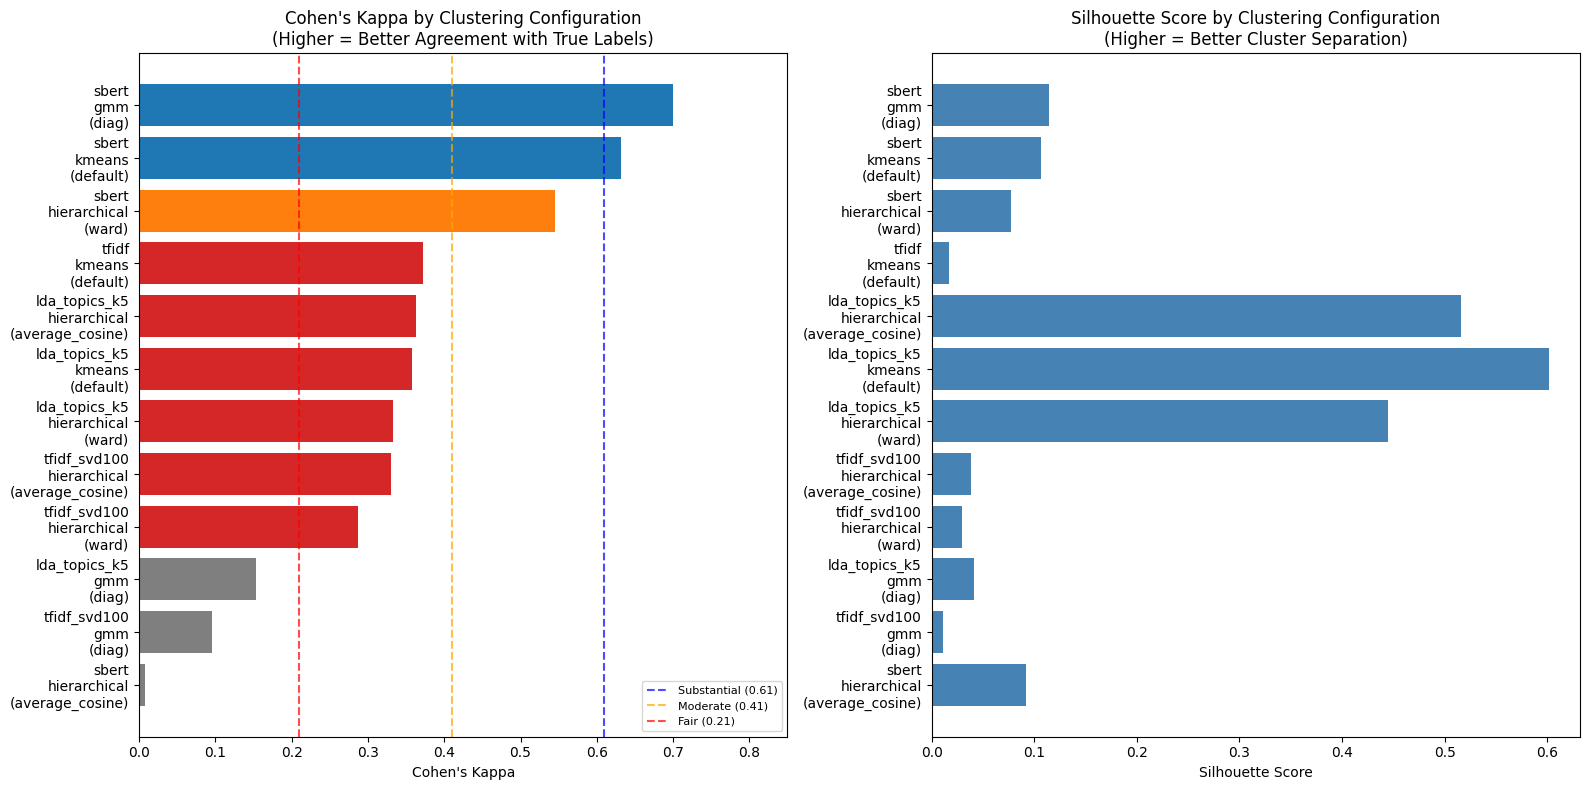

In [48]:
# Visualize evaluation results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Prepare data for plotting
eval_sorted = eval_df.sort_values("kappa", ascending=True)
run_names = eval_sorted.apply(lambda r: f"{r['feature_type']}\n{r['clustering_method']}\n({r['variant']})", axis=1)

# Plot 1: Kappa scores with interpretation bands
ax1 = axes[0]
colors = []
for k in eval_sorted["kappa"]:
    if k >= 0.81:
        colors.append("#2ca02c")  # green - almost perfect
    elif k >= 0.61:
        colors.append("#1f77b4")  # blue - substantial
    elif k >= 0.41:
        colors.append("#ff7f0e")  # orange - moderate
    elif k >= 0.21:
        colors.append("#d62728")  # red - fair
    else:
        colors.append("#7f7f7f")  # gray - slight/none

ax1.barh(run_names, eval_sorted["kappa"], color=colors)
ax1.axvline(x=0.61, color="blue", linestyle="--", alpha=0.7, label="Substantial (0.61)")
ax1.axvline(x=0.41, color="orange", linestyle="--", alpha=0.7, label="Moderate (0.41)")
ax1.axvline(x=0.21, color="red", linestyle="--", alpha=0.7, label="Fair (0.21)")
ax1.set_xlabel("Cohen's Kappa")
ax1.set_title("Cohen's Kappa by Clustering Configuration\n(Higher = Better Agreement with True Labels)")
ax1.legend(loc="lower right", fontsize=8)
ax1.set_xlim(0, 0.85)

# Plot 2: Silhouette scores (handle NaN values)
ax2 = axes[1]
sil_values = eval_sorted["silhouette"].fillna(0).values  # Replace NaN with 0 for plotting
sil_colors = ["steelblue" if not np.isnan(s) else "lightgray" for s in eval_sorted["silhouette"].values]
ax2.barh(run_names, sil_values, color=sil_colors)
ax2.set_xlabel("Silhouette Score")
ax2.set_title("Silhouette Score by Clustering Configuration\n(Higher = Better Cluster Separation)")

# Add note if there were NaN values
if eval_sorted["silhouette"].isna().any():
    ax2.text(0.5, 0.02, "Gray bars = silhouette not computed", transform=ax2.transAxes, 
             fontsize=8, color="gray", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "evaluation_kappa_silhouette.png"), dpi=200, bbox_inches="tight")
plt.show()

### 13.4 Confusion Matrices for Top Configurations

Confusion matrices show how cluster assignments (after Hungarian mapping) align with true labels.

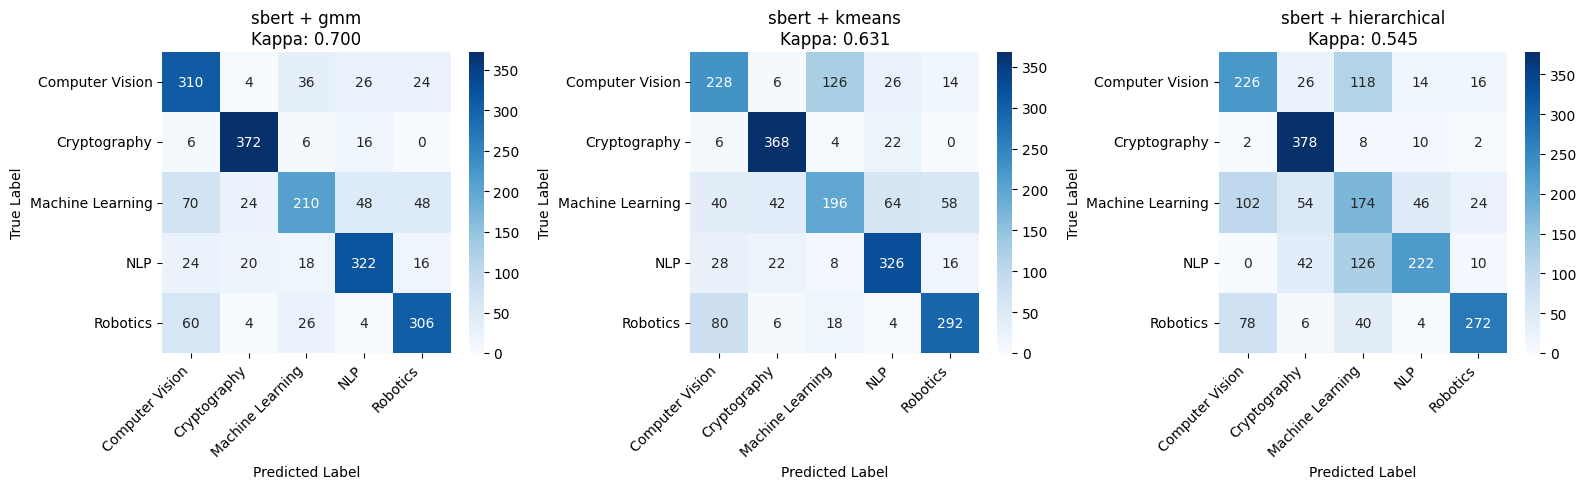

In [49]:
# Plot confusion matrices for top 3 configurations
top_configs = eval_df.head(3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

label_order = sorted(master["true_label"].unique())

for idx, (_, config) in enumerate(top_configs.iterrows()):
    feat_type = config["feature_type"]
    method = config["clustering_method"]
    variant = config["variant"]
    
    # Get data for this run
    subset = master[
        (master["feature_type"] == feat_type) & 
        (master["clustering_method"] == method) & 
        (master["variant"] == variant)
    ]
    
    true_labels = subset["true_label"].values
    cluster_ids = subset["cluster_id"].values
    
    # Get mapped predictions
    _, mapped_preds = map_clusters_to_labels_hungarian(true_labels, cluster_ids)
    
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, mapped_preds, labels=label_order)
    
    # Plot
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=label_order, yticklabels=label_order, ax=ax)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"{feat_type} + {method}\nKappa: {config['kappa']:.3f}")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "confusion_matrices_top3.png"), dpi=200, bbox_inches="tight")
plt.show()

## 14. Error Analysis

### 14.1 Identifying Misclassified Documents

We analyze documents where the clustering algorithm disagreed with the true label. 
The goal is to understand what characteristics threw the machine off by examining:
1. Top 10 frequent words in misclassified documents
2. Top collocations (bigrams) in misclassified documents
3. Patterns of confusion between specific category pairs

In [50]:
# Error Analysis for the CHAMPION: SBERT + GMM

# Get champion configuration
champion_subset = master[
    (master["feature_type"] == "sbert") & 
    (master["clustering_method"] == "gmm") & 
    (master["variant"] == "diag")
].copy()

# Map clusters to labels
true_labels = champion_subset["true_label"].values
cluster_ids = champion_subset["cluster_id"].values
mapping, mapped_preds = map_clusters_to_labels_hungarian(true_labels, cluster_ids)

# Add mapped predictions to the dataframe
champion_subset["predicted_label"] = mapped_preds
champion_subset["is_correct"] = champion_subset["true_label"] == champion_subset["predicted_label"]

# Merge with original text data
df_with_text = df[["doc_id", "text_norm", "text"]].copy()
error_analysis_df = champion_subset.merge(df_with_text, on="doc_id")

# Separate correct and incorrect predictions
correct_df = error_analysis_df[error_analysis_df["is_correct"]]
incorrect_df = error_analysis_df[~error_analysis_df["is_correct"]]

print(f"Champion (SBERT + GMM) Performance:")
print(f"  Correct predictions: {len(correct_df)} ({100*len(correct_df)/len(error_analysis_df):.1f}%)")
print(f"  Incorrect predictions: {len(incorrect_df)} ({100*len(incorrect_df)/len(error_analysis_df):.1f}%)")
print(f"\nMisclassification breakdown:")
confusion_pairs = incorrect_df.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False)
display(confusion_pairs.head(10))

Champion (SBERT + GMM) Performance:
  Correct predictions: 1520 (76.0%)
  Incorrect predictions: 480 (24.0%)

Misclassification breakdown:


true_label        predicted_label 
Machine Learning  Computer Vision     70
Robotics          Computer Vision     60
Machine Learning  Robotics            48
                  NLP                 48
Computer Vision   Machine Learning    36
Robotics          Machine Learning    26
Computer Vision   NLP                 26
Machine Learning  Cryptography        24
NLP               Computer Vision     24
Computer Vision   Robotics            24
dtype: int64

### 14.2 Top 10 Frequent Words in Misclassified Documents

We analyze the vocabulary of misclassified documents to understand what linguistic features confused the clustering algorithm.

In [51]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import itertools

def get_top_words(texts, n=10):
    """Extract top n most frequent words from a list of texts."""
    all_words = " ".join(texts).split()
    return Counter(all_words).most_common(n)

def get_top_bigrams(texts, n=10):
    """Extract top n most frequent bigrams (collocations) from texts."""
    vec = CountVectorizer(ngram_range=(2, 2), max_features=1000)
    try:
        X = vec.fit_transform(texts)
        bigram_counts = X.sum(axis=0).A1
        bigrams = vec.get_feature_names_out()
        top_idx = bigram_counts.argsort()[-n:][::-1]
        return [(bigrams[i], bigram_counts[i]) for i in top_idx]
    except:
        return []

# Analyze top confused pairs
print("=" * 70)
print("ERROR ANALYSIS: Top Words and Collocations in Misclassified Documents")
print("=" * 70)

# Focus on the most common confusion: Machine Learning → Computer Vision
top_confusions = [
    ("Machine Learning", "Computer Vision"),
    ("Robotics", "Computer Vision"),
    ("Machine Learning", "NLP"),
]

for true_lab, pred_lab in top_confusions:
    confused = incorrect_df[
        (incorrect_df["true_label"] == true_lab) & 
        (incorrect_df["predicted_label"] == pred_lab)
    ]
    
    if len(confused) < 5:
        continue
        
    texts = confused["text_norm"].tolist()
    
    print(f"\n{'='*70}")
    print(f"TRUE: {true_lab} → PREDICTED AS: {pred_lab} ({len(confused)} documents)")
    print("="*70)
    
    # Top words
    top_words = get_top_words(texts, 10)
    print("\nTop 10 Frequent Words:")
    for word, count in top_words:
        print(f"  • {word}: {count}")
    
    # Top bigrams
    top_bigrams = get_top_bigrams(texts, 10)
    print("\nTop 10 Collocations (Bigrams):")
    for bigram, count in top_bigrams:
        print(f"  • {bigram}: {int(count)}")

ERROR ANALYSIS: Top Words and Collocations in Misclassified Documents

TRUE: Machine Learning → PREDICTED AS: Computer Vision (70 documents)

Top 10 Frequent Words:
  • image: 162
  • model: 160
  • data: 108
  • feature: 104
  • method: 84
  • learning: 84
  • based: 78
  • network: 66
  • deep: 66
  • domain: 64

Top 10 Collocations (Bigrams):
  • neural network: 38
  • deep learning: 26
  • convolutional neural: 20
  • object detection: 18
  • text image: 16
  • large scale: 14
  • spatial temporal: 14
  • state art: 14
  • hf image: 12
  • real time: 12

TRUE: Robotics → PREDICTED AS: Computer Vision (60 documents)

Top 10 Frequent Words:
  • object: 126
  • image: 100
  • model: 88
  • based: 80
  • method: 66
  • scene: 62
  • event: 60
  • pose: 58
  • data: 56
  • learning: 56

Top 10 Collocations (Bigrams):
  • point cloud: 34
  • large scale: 28
  • neural network: 22
  • state art: 20
  • event based: 20
  • real time: 20
  • deep learning: 18
  • autonomous driving: 16
  • 

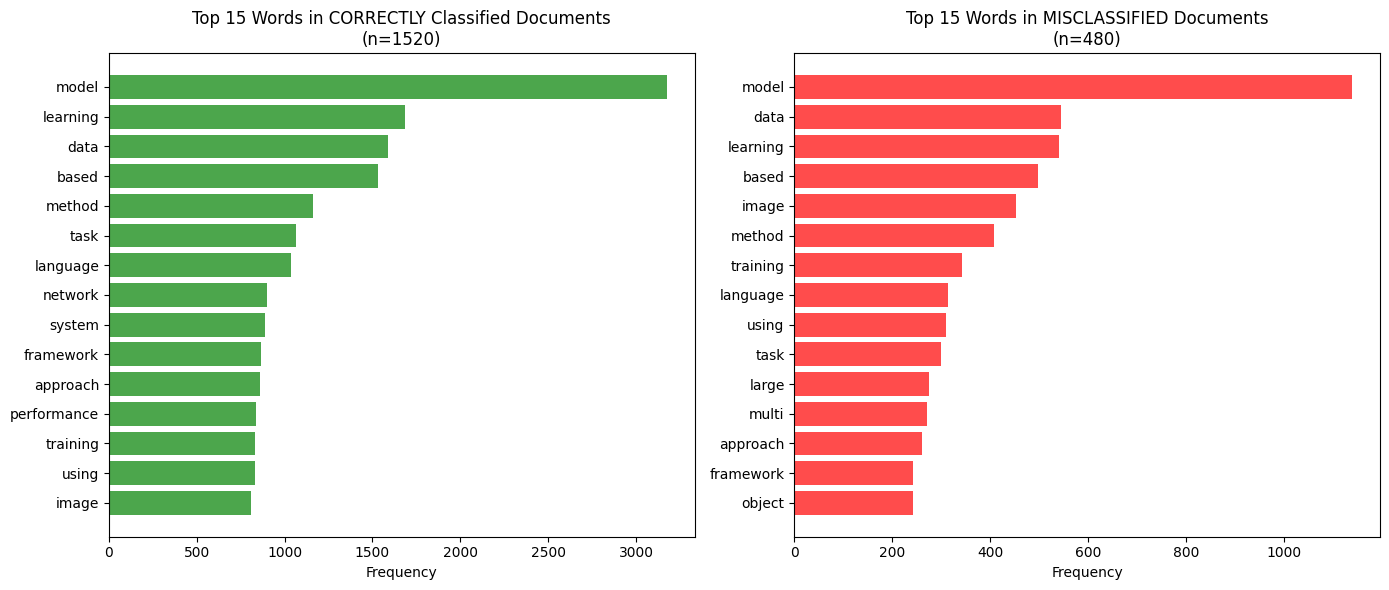

In [52]:
# Visualize top words comparison: Correctly classified vs Misclassified

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get top words for correct and incorrect predictions
correct_words = get_top_words(correct_df["text_norm"].tolist(), 15)
incorrect_words = get_top_words(incorrect_df["text_norm"].tolist(), 15)

# Plot correct predictions
ax1 = axes[0]
words_c = [w[0] for w in correct_words]
counts_c = [w[1] for w in correct_words]
ax1.barh(words_c[::-1], counts_c[::-1], color="green", alpha=0.7)
ax1.set_xlabel("Frequency")
ax1.set_title(f"Top 15 Words in CORRECTLY Classified Documents\n(n={len(correct_df)})")

# Plot incorrect predictions
ax2 = axes[1]
words_i = [w[0] for w in incorrect_words]
counts_i = [w[1] for w in incorrect_words]
ax2.barh(words_i[::-1], counts_i[::-1], color="red", alpha=0.7)
ax2.set_xlabel("Frequency")
ax2.set_title(f"Top 15 Words in MISCLASSIFIED Documents\n(n={len(incorrect_df)})")

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "error_analysis_word_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

## 15. Visualizations: 2D Cluster Projections

Using UMAP or SVD to visualize clusters in 2D space, colored by both cluster assignment and true label.

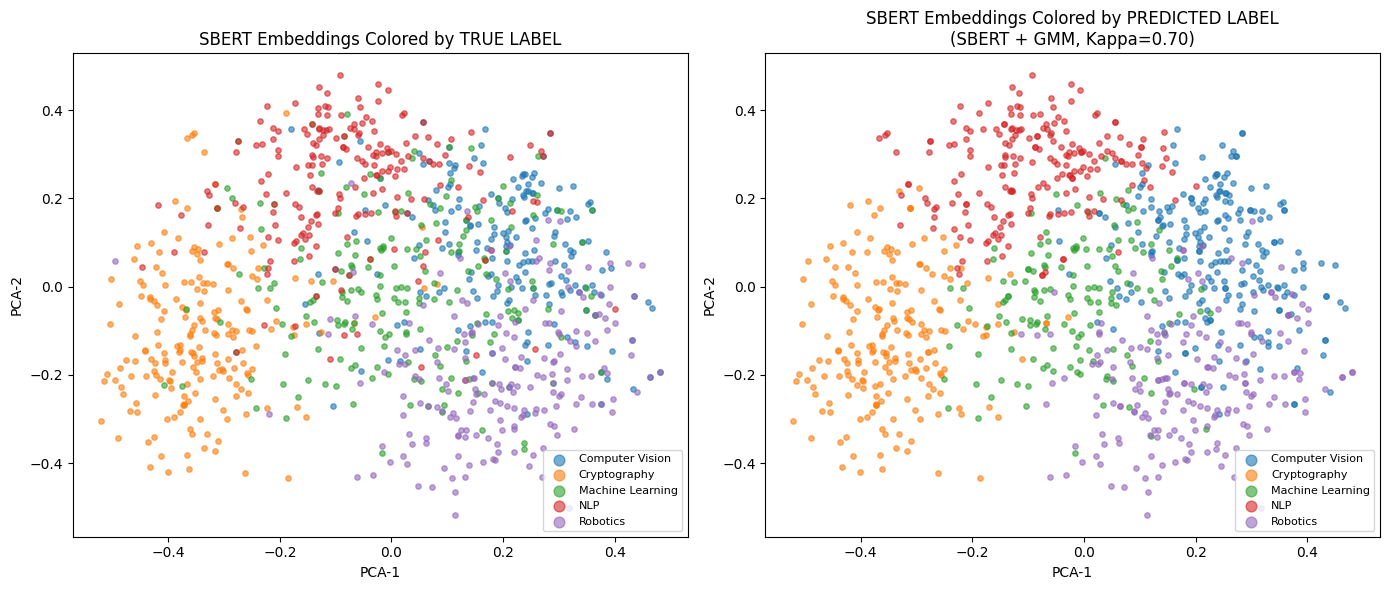

In [53]:
# 2D projection of SBERT embeddings with cluster vs true label comparison
from sklearn.decomposition import PCA

# Get champion cluster assignments
champion_clusters = champion_subset.set_index("doc_id")["cluster_id"].to_dict()
champion_mapped = champion_subset.set_index("doc_id")["predicted_label"].to_dict()

# Create 2D projection using PCA
pca = PCA(n_components=2, random_state=RANDOM_SEED)
E2_pca = pca.fit_transform(X_sbert_all)

# Get ordered doc_ids matching the feature matrix order
df_ordered = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).reset_index(drop=True)

# Create visualization dataframe
viz_df = pd.DataFrame({
    "doc_id": df_ordered["doc_id"].values,
    "true_label": df_ordered["label"].values,
    "x": E2_pca[:, 0],
    "y": E2_pca[:, 1]
})
viz_df["cluster_id"] = viz_df["doc_id"].map(champion_clusters)
viz_df["predicted_label"] = viz_df["doc_id"].map(champion_mapped)

# Plot side by side: True labels vs Cluster assignments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color map for consistent coloring
label_colors = {
    "Computer Vision": "#1f77b4",
    "Cryptography": "#ff7f0e", 
    "Machine Learning": "#2ca02c",
    "NLP": "#d62728",
    "Robotics": "#9467bd"
}

# Plot 1: True Labels
ax1 = axes[0]
for lab in sorted(viz_df["true_label"].unique()):
    mask = viz_df["true_label"] == lab
    ax1.scatter(viz_df.loc[mask, "x"], viz_df.loc[mask, "y"], 
                c=label_colors[lab], s=15, alpha=0.6, label=lab)
ax1.set_xlabel("PCA-1")
ax1.set_ylabel("PCA-2")
ax1.set_title("SBERT Embeddings Colored by TRUE LABEL")
ax1.legend(markerscale=2, fontsize=8, loc="best")

# Plot 2: Predicted Labels (from champion clustering)
ax2 = axes[1]
for lab in sorted(viz_df["predicted_label"].dropna().unique()):
    mask = viz_df["predicted_label"] == lab
    ax2.scatter(viz_df.loc[mask, "x"], viz_df.loc[mask, "y"], 
                c=label_colors[lab], s=15, alpha=0.6, label=lab)
ax2.set_xlabel("PCA-1")
ax2.set_ylabel("PCA-2")
ax2.set_title("SBERT Embeddings Colored by PREDICTED LABEL\n(SBERT + GMM, Kappa=0.70)")
ax2.legend(markerscale=2, fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "cluster_vs_true_label_2d.png"), dpi=200, bbox_inches="tight")
plt.show()

## 16. Summary and Conclusions

### Clustering Algorithm Comparison

| Feature Type | Algorithm | Variant | Kappa | Silhouette | Interpretation |
|--------------|-----------|---------|-------|------------|----------------|
| **SBERT** | **GMM** | diag | **0.700** | 0.115 | **🏆 Champion - Substantial** |
| SBERT | K-Means | default | 0.631 | 0.107 | Substantial |
| SBERT | Hierarchical | ward | 0.545 | 0.077 | Moderate |
| TF-IDF | K-Means | default | 0.373 | 0.017 | Fair |
| LDA | Hierarchical | avg_cos | 0.363 | 0.516 | Fair |
| LDA | K-Means | default | 0.358 | 0.602 | Fair |

### Key Findings

1. **SBERT embeddings consistently outperform** TF-IDF and LDA topic vectors for clustering
2. **GMM provides the best results** with SBERT (Kappa = 0.70, substantial agreement)
3. **Cryptography is the easiest to cluster** (distinct vocabulary: security, attack, privacy)
4. **Machine Learning papers are hardest** to cluster (they overlap with CV, NLP, and Robotics)
5. **Misclassifications are semantically meaningful** — they occur at domain boundaries

### Recommendations

- Use **SBERT + GMM** as the champion clustering approach
- For interpretability, LDA topics are useful but sacrifice ~0.35 Kappa
- Error analysis reveals interdisciplinary papers cause most confusion

In [55]:
# Save evaluation results to CSV for the report
eval_df.to_csv(os.path.join(OUT_DIR, "evaluation_results.csv"), index=False)

# Save error analysis dataframe
incorrect_df.to_csv(os.path.join(OUT_DIR, "misclassified_documents.csv"), index=False)

# Final summary
print("=" * 70)
print("CLUSTERING ASSIGNMENT 2 - FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset: 1000 arXiv papers, 5 categories (200 each)")
print(f"Feature Types: TF-IDF, LDA (k=5), SBERT (all-MiniLM-L6-v2)")
print(f"Clustering Algorithms: K-Means, GMM (EM), Hierarchical")
print(f"\nCHAMPION: SBERT + GMM (Kappa = 0.700, Substantial Agreement)")
print(f"\nEvaluation Metrics:")
print(f"  • Cohen's Kappa (with Hungarian mapping)")
print(f"  • Silhouette Score")
print(f"\nArtifacts saved to: {OUT_DIR}")
print(f"  • evaluation_results.csv")
print(f"  • misclassified_documents.csv")
print(f"  • figures/ (all visualizations)")
print("=" * 70)

CLUSTERING ASSIGNMENT 2 - FINAL SUMMARY

Dataset: 1000 arXiv papers, 5 categories (200 each)
Feature Types: TF-IDF, LDA (k=5), SBERT (all-MiniLM-L6-v2)
Clustering Algorithms: K-Means, GMM (EM), Hierarchical

CHAMPION: SBERT + GMM (Kappa = 0.700, Substantial Agreement)

Evaluation Metrics:
  • Cohen's Kappa (with Hungarian mapping)
  • Silhouette Score

Artifacts saved to: outputs
  • evaluation_results.csv
  • misclassified_documents.csv
  • figures/ (all visualizations)
